7

In [109]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=10000, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

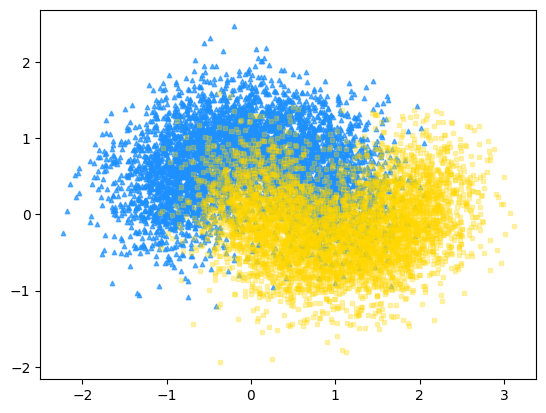

In [110]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], color="dodgerblue", s=10, alpha=0.7, marker="^")
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], color="gold", s=10, alpha=0.3, marker="s")

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt_clf = DecisionTreeClassifier(random_state=42)
cross_val_score(dt_clf, X_train, y_train, cv=10).mean()

np.float64(0.7938666666666666)

In [114]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [None, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_split": [2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48],
    "max_leaf_nodes": [None, 2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
}

grid_search = GridSearchCV(dt_clf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 2, ...], 'max_leaf_nodes': [None, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [115]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False).head(20)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_leaf_nodes,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1245,0.027132,0.000710,0.002104,0.000042,7,40,40,"{'max_depth': 7, 'max_leaf_nodes': 40, 'min_sa...",0.852667,0.861333,0.876000,0.857333,0.872000,0.863867,0.008808,1
1208,0.026166,0.002520,0.002179,0.000268,7,28,48,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1204,0.031114,0.003668,0.003028,0.001334,7,28,32,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1205,0.027010,0.001268,0.002087,0.000077,7,28,36,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1206,0.028430,0.002171,0.002169,0.000079,7,28,40,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1202,0.025964,0.001916,0.002067,0.000072,7,28,24,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1200,0.027798,0.002560,0.004211,0.004327,7,28,16,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1203,0.030788,0.003554,0.002303,0.000150,7,28,28,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1199,0.033333,0.004544,0.002319,0.000212,7,28,12,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2
1196,0.026607,0.002403,0.002126,0.000105,7,28,2,"{'max_depth': 7, 'max_leaf_nodes': 28, 'min_sa...",0.855333,0.859333,0.875333,0.856000,0.872667,0.863733,0.008533,2


In [127]:
best_model = DecisionTreeClassifier(
    max_depth=7, 
    max_leaf_nodes=30, 
    min_samples_split=50
) 
cross_val_score(best_model, X_train, y_train, cv=10).mean()

np.float64(0.8641333333333334)

In [128]:
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)

0.8532

Similar score for cv and test means its not overfitting.